# Metacognitive efficiency with meta-d′

> **Level** Intermediate · **Time** 20 minutes · **Prerequisites** basic signal detection theory ·
> **cpm components** [`EstimatorMetaD`](#cpm.applications.signal_detection.EstimatorMetaD) ·
> **Data** [`load_metacognition_data`](#cpm.datasets.load_metacognition_data)

Metacognition is the ability to monitor and evaluate our own decisions.
One way to measure it is to ask people how confident they are after each decision: if their metacognition is good, they are more confident when they are right than when they are wrong.

Meta-d′ (Maniscalco & Lau, 2012) measures how well confidence ratings discriminate correct from incorrect decisions, in the same units as the sensitivity of the decisions themselves, $d'$.
In this example, we estimate meta-d′ with [`EstimatorMetaD`](#cpm.applications.signal_detection.EstimatorMetaD) for participants of a perceptual decision-making task.

**What you'll learn**

- what $d'$, meta-$d'$ and the M-ratio measure,
- how to prepare trial-level decision and confidence data,
- how to estimate meta-$d'$ for each participant, and interpret the estimates.

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)

0.25.7.dev0


## Meta-d′ in brief

In signal detection theory, $d'$ measures how well an observer discriminates two stimulus classes, S1 and S2, from the distance between the internal evidence distributions of the two classes.
This is the **type 1** task: deciding which stimulus was shown.

The **type 2** task is to discriminate one's own correct decisions from incorrect ones with confidence ratings.
Meta-$d'$ is the $d'$ that an ideal metacognitive observer would need to produce the confidence ratings we observe.
If confidence uses all the information that the decision was based on, meta-$d'$ equals $d'$.
If information is lost between the decision and the confidence rating, meta-$d'$ is smaller than $d'$.

Because meta-$d'$ and $d'$ are in the same units, their ratio, the **M-ratio**, is a measure of metacognitive efficiency that does not depend on how good the decisions themselves are (Fleming & Lau, 2014):

$$
\text{M-ratio} = \frac{\text{meta-}d'}{d'}
$$

An M-ratio of 1 means ideal metacognition; values below 1 mean that confidence is less informative than it could be.

## The data

The data come from a perceptual decision-making task with confidence ratings, played on smartphones as part of the BrainExplorer platform (Marzuki et al., 2025).
On each trial, participants saw a brief display of two kinds of aliens and decided which kind was more numerous, then rated their confidence from 0 ("totally guessing") to 100 ("totally certain").

In [2]:
from cpm.datasets import load_metacognition_data

data = load_metacognition_data()
data.head()

,participant,signal,stimulus_intensity,response,confidence,accuracy
0,1,1,8,0,56,0
1,1,0,12,0,65,1
2,1,0,12,1,22,0
3,1,1,16,1,62,1
4,1,0,16,0,60,1


The columns are:

- `participant`: the participant number,
- `signal`: which kind of alien was more numerous (0 for S1, 1 for S2),
- `stimulus_intensity`: the difference in the number of aliens, which a staircase adjusted to keep accuracy at about 70%,
- `response`: the decision of the participant (0 for S1, 1 for S2),
- `confidence`: the confidence rating (0 to 100),
- `accuracy`: whether the decision was correct.

In [3]:
trials = data.groupby("participant").size()
print(f"{data.participant.nunique()} participants, {trials.median():.0f} trials each, accuracy {data.accuracy.mean():.2f}")

300 participants, 80 trials each, accuracy 0.73


Before fitting anything, we can check whether confidence tracks accuracy at all: on average, participants should be more confident when they are correct.

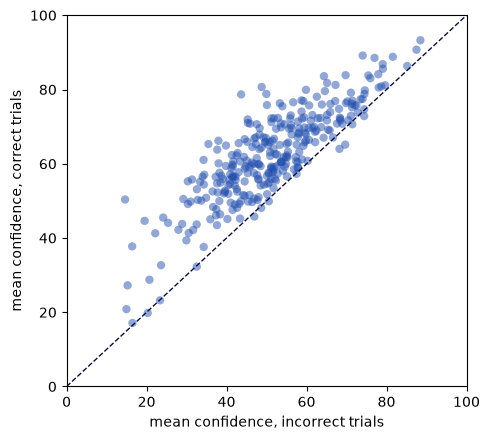

In [4]:
confidence = data.groupby(["participant", "accuracy"]).confidence.mean().unstack()

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(confidence[0], confidence[1], alpha=0.5, color="#2350b0", edgecolor="none")
ax.plot([0, 100], [0, 100], color="#0c0c45", linestyle="--", linewidth=1)
ax.set_xlabel("mean confidence, incorrect trials")
ax.set_ylabel("mean confidence, correct trials")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Most participants lie above the diagonal: they are more confident when they are correct.
Meta-$d'$ quantifies how well confidence separates the two, given how well each participant performed the task.

## Estimating meta-d′

[`EstimatorMetaD`](#cpm.applications.signal_detection.EstimatorMetaD) fits the meta-$d'$ model of Maniscalco and Lau (2012) to the data of each participant.
It needs the columns `signal`, `response`, `confidence` and `accuracy`; it also currently requires an `observed` column, for which we use the confidence ratings.

The model works with discrete confidence levels, so the estimator first bins the ratings of each participant into `bins` levels of roughly equal size, with [`bin_ratings`](#cpm.utils.metad.bin_ratings).
When many ratings are identical, for example when a participant often reports 100, equal-sized bins are not possible, and the estimator adjusts the bins; it prints a message when it does.
With `prior=True`, the estimates are regularised by weak priors, which makes the fits more stable with few trials.

To keep this example fast, we fit the first 40 participants.

In [5]:
import warnings

from cpm.applications.signal_detection import EstimatorMetaD

# the optimiser explores regions where the likelihood is undefined; these warnings are harmless
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="delta_grad == 0.0")

data["observed"] = data["confidence"]
sample = data[data.participant.isin(data.participant.unique()[:40])]

estimator = EstimatorMetaD(
    data=sample.groupby("participant"),
    bins=4,
    prior=True,
    parallel=False,
    display=False,
)
estimator.optimise()

Correcting for bias in high confidence ratings


Correcting for bias in high confidence ratings


Correction for bias in low confidence ratings


Correction for bias in low confidence ratings


In [6]:
estimates = estimator.export()
estimates[["ppt", "d", "meta_d", "m_ratio", "m_diff"]].head()

,ppt,d,meta_d,m_ratio,m_diff
0,1,1.359242,1.314121,0.966805,-0.045121
1,2,1.029980,0.584894,0.567869,-0.445087
2,3,1.039519,0.405863,0.390434,-0.633655
3,4,1.272349,0.737918,0.579965,-0.534431
4,5,1.256566,1.382703,1.100382,0.126137


For each participant, `d` is $d'$, `meta_d` is meta-$d'$, `m_ratio` is their ratio and `m_diff` their difference.
The export also holds the estimated confidence criteria, and the observed and predicted confidence rating frequencies.

## Results

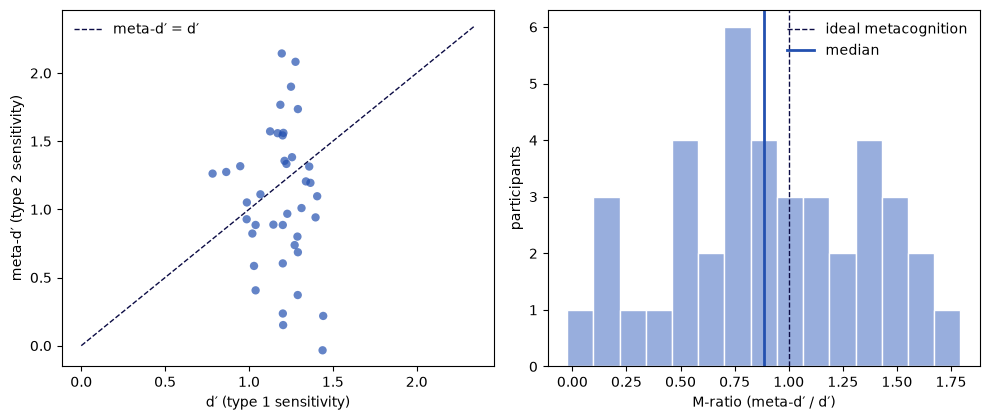

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].scatter(estimates["d"], estimates["meta_d"], alpha=0.7, color="#2350b0", edgecolor="none")
limit = max(estimates["d"].max(), estimates["meta_d"].max()) + 0.2
axes[0].plot([0, limit], [0, limit], color="#0c0c45", linestyle="--", linewidth=1, label="meta-d′ = d′")
axes[0].set_xlabel("d′ (type 1 sensitivity)")
axes[0].set_ylabel("meta-d′ (type 2 sensitivity)")
axes[0].legend(frameon=False)

axes[1].hist(estimates["m_ratio"], bins=15, color="#98aedd", edgecolor="white")
axes[1].axvline(1, color="#0c0c45", linestyle="--", linewidth=1, label="ideal metacognition")
axes[1].axvline(estimates["m_ratio"].median(), color="#2350b0", linewidth=2, label="median")
axes[1].set_xlabel("M-ratio (meta-d′ / d′)")
axes[1].set_ylabel("participants")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

In [8]:
estimates[["d", "meta_d", "m_ratio"]].describe().round(2)

,d,meta_d,m_ratio
count,40.00,40.00,40.00
mean,1.19,1.07,0.92
std,0.15,0.52,0.46
min,0.78,-0.03,-0.02
25%,1.11,0.78,0.61
50%,1.20,1.07,0.89
75%,1.29,1.36,1.30
max,1.44,2.14,1.79


Because the staircase kept accuracy at about 70%, $d'$ is similar across participants, while meta-$d'$ varies much more: participants differ far more in how well their confidence tracks their accuracy than in how well they do the task.
Some participants have an M-ratio close to 1, or even above it, while others have little metacognitive insight.

Keep in mind that 80 trials per participant is few for estimating meta-$d'$, so individual estimates are noisy.
For group-level questions, hierarchical estimation of meta-$d'$ (Fleming, 2017) is more reliable.

## Summary and next steps

You estimated $d'$, meta-$d'$ and the M-ratio for each participant of a perceptual decision-making task with [`EstimatorMetaD`](#cpm.applications.signal_detection.EstimatorMetaD).
To prepare your own data, [`count_trials`](#cpm.utils.metad.count_trials) converts trial-level data into the response counts that the meta-$d'$ model uses, and [`bin_ratings`](#cpm.utils.metad.bin_ratings) bins continuous confidence ratings.
To fit many participants faster, see the how-to guide on [parallel fitting](../how-to/parallelise-fitting.md).

## References

Fleming, S. M. (2017). HMeta-d: Hierarchical Bayesian estimation of metacognitive efficiency from confidence ratings. *Neuroscience of Consciousness*, 2017(1), nix007. https://doi.org/10.1093/nc/nix007

Fleming, S. M., & Lau, H. C. (2014). How to measure metacognition. *Frontiers in Human Neuroscience*, 8, 443. https://doi.org/10.3389/fnhum.2014.00443

Maniscalco, B., & Lau, H. (2012). A signal detection theoretic approach for estimating metacognitive sensitivity from confidence ratings. *Consciousness and Cognition*, 21(1), 422–430. https://doi.org/10.1016/j.concog.2011.09.021

Marzuki, A., Kosina, L., Dome, L., Hewitt, S., & Hauser, T. (2025). Metacognitive antecedents to states of mental ill-health: Drops in confidence precede symptoms of OCD. *Research Square*. https://doi.org/10.21203/rs.3.rs-7544256/v1